In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime


from rubin_sim.data import get_baseline
from os.path import basename


In [2]:
# Read in the current baseline
db_file = get_baseline()
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)


Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 g 20774 799 26


/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 i 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 r 50337 799 63
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 y 63121 799 79
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 z 73508 799 92
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 g 20774 799 26


/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 i 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 r 50337 799 63
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 y 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 z 88689 799 111
time to run in SNe single-core 0:01:34.335613


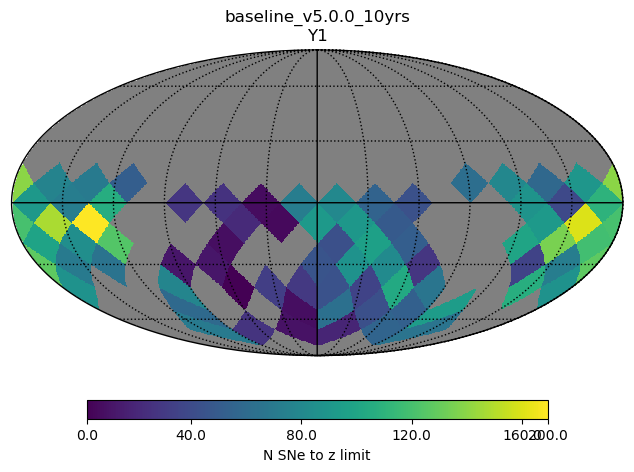

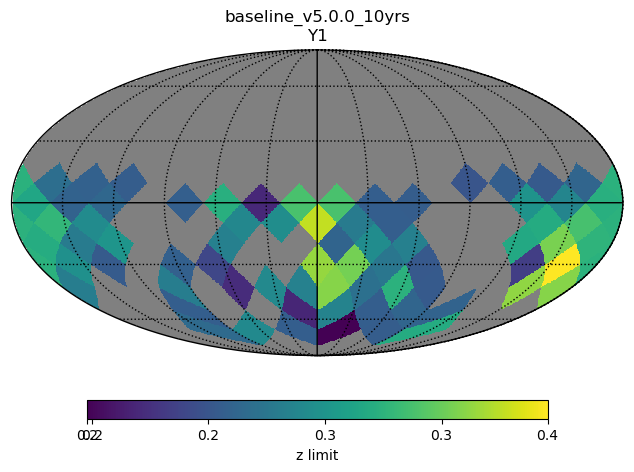

In [3]:
t1 = datetime.datetime.now()
# The SNe metric that computes multiple things
summary_stats = []
nside = 4

info = maf.empty_info()
info["run_name"] = run_name
info["observations_subset"] = "Y1"
sub_data = visits_array[np.where(visits_array["night"] <=365)]
sl = maf.Slicer(nside=nside)
metric = maf.SNNSNMetric()
sn_array, info = sl(sub_data, metric, info=info)
pm = maf.PlotMoll(info=info)

# Need to split the info dict so 
# files don't clobber
metric_basename = info["metric: name"]
fig = pm(sn_array["n_sn"], unit="N SNe to z limit")
info["metric: name"] = metric_basename + " N SN"
# fig_saver(fig, info=info)
fig = pm(sn_array["zlim"], unit="z limit")
info["metric: name"] = metric_basename + " z lim"
#fig_saver(fig, info=info)

summary_stats.append(maf.gen_summary_row(info, "sum N SNe", np.nansum(sn_array["n_sn"])))
summary_stats.append(maf.gen_summary_row(info, "mean z limit", np.nanmean(sn_array["zlim"])))
summary_stats.append(maf.gen_summary_row(info, "median z limit", np.nanmedian(sn_array["zlim"])))

t2 = datetime.datetime.now()
print("time to run in SNe single-core", t2-t1)


In [4]:
# Pretty output of summary stats
pd.DataFrame.from_dict(summary_stats)



,run_name,metric: name,metric: col,metric: unit,observations_subset,slicer: nside,summary_name,value,caption,group,subgroup
0,baseline_v5.0.0_10yrs,SNNSNMetric z lim,,,Y1,4,sum N SNe,5171.128903,,,
1,baseline_v5.0.0_10yrs,SNNSNMetric z lim,,,Y1,4,mean z limit,0.271176,,,
2,baseline_v5.0.0_10yrs,SNNSNMetric z lim,,,Y1,4,median z limit,0.267078,,,


In [14]:
# Read in the current baseline
db_file = "comp_survey_v5.2.0_10yrs.db" # "baseline_v5.1.1_1yrs.db" #"templates_fast_mixed_v5.2.0_10yrs.db"
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)


In [15]:
t1 = datetime.datetime.now()
# The SNe metric that computes multiple things
summary_stats = []
nside = 4

info = maf.empty_info()
info["run_name"] = run_name
info["observations_subset"] = "Y1"
sub_data = visits_array[np.where(  ( visits_array["night"] < 366)) ]
# sub_data["visitExposureTime"] = sub_data["visitExposureTime"] 
sl = maf.Slicer(nside=nside)
metric = maf.SNNSNMetric()
sn_array, info = sl(sub_data, metric, info=info)
pm = maf.PlotMoll(info=info)

# Need to split the info dict so 
# files don't clobber
metric_basename = info["metric: name"]
fig = pm(sn_array["n_sn"], unit="N SNe to z limit")
info["metric: name"] = metric_basename + " N SN"
# fig_saver(fig, info=info)
fig = pm(sn_array["zlim"], unit="z limit")
info["metric: name"] = metric_basename + " z lim"
# fig_saver(fig, info=info)

summary_stats.append(maf.gen_summary_row(info, "sum N SNe", np.nansum(sn_array["n_sn"])))
summary_stats.append(maf.gen_summary_row(info, "mean z limit", np.nanmean(sn_array["zlim"])))
summary_stats.append(maf.gen_summary_row(info, "median z limit", np.nanmedian(sn_array["zlim"])))

t2 = datetime.datetime.now()
print("time to run in SNe single-core", t2-t1)


time to run in SNe single-core 0:00:00.684514


/Users/yoachim/git_repos/rubin_sim/rubin_sim/splat/plots/plots.py:162: UserWarning: No finite values to plot, returning empty figure
  warnings.warn("No finite values to plot, returning empty figure")


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [13]:
# Pretty output of summary stats
pd.DataFrame.from_dict(summary_stats)


,run_name,metric: name,metric: col,metric: unit,observations_subset,slicer: nside,summary_name,value,caption,group,subgroup
0,baseline_v5.1.1_1yrs,SNNSNMetric z lim,,,Y1,4,sum N SNe,3826.825310,,,
1,baseline_v5.1.1_1yrs,SNNSNMetric z lim,,,Y1,4,mean z limit,0.247670,,,
2,baseline_v5.1.1_1yrs,SNNSNMetric z lim,,,Y1,4,median z limit,0.245166,,,
